In [97]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

import warnings
from IPython.display import Image, display
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn import linear_model

from mpl_toolkits.mplot3d import Axes3D


In [98]:
candy_df_filepath = os.path.abspath("Regresion_Lineal/candy.csv")
df = pd.read_csv("candy.csv")
df

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,Twizzlers,No,Yes,No,No,No,No,No,No,No,0.220,0.116,45.466282
79,79,Warheads,No,Yes,No,No,No,No,Yes,No,No,0.093,0.116,39.011898
80,80,Welch's Fruit Snacks,No,Yes,No,No,No,No,No,No,Yes,0.313,0.313,44.375519
81,81,Werther's Original Caramel,No,No,Yes,No,No,No,Yes,No,No,0.186,0.267,41.904308


In [99]:
# Datos
X1 = df[['pricepercent']]  # porcentaje precio
X2 = df[[ 'sugarpercent']]  # porcentaje azucar
Y  = df[['winpercent']] # ganacias porcentaje



In [100]:
# Matriz de diseño
A = np.column_stack([np.ones_like(X1), X1, X2])
b0, b1, b2 = np.linalg.lstsq(A, Y, rcond=None)[3]

print(f"Modelo: Y = {b0:.2f} + {b1:.2f}*X1 + {b2:.2f}*X2")

Modelo: Y = 11.15 + 2.40*X1 + 2.09*X2


In [ ]:
# Predicción
x1_new = 0.95
x2_new = 100
y_pred = b0 + b1*x1_new + b2*x2_new
print(f"Predicción para precio producto={x1_new} $ y ganacias={x2_new}: {y_pred:.2f} $")

Predicción para precio producto=0.95 $ y ganacias=100: 222.60 $


In [102]:
regr = linear_model.LinearRegression()
regr.fit(X1, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
#Coeficiente de correlacion
print('Coeficientes de correlacion: ', regr.coef_)

Coeficientes de correlacion:  [[17.18681473]]


ValueError: x and y must be the same size

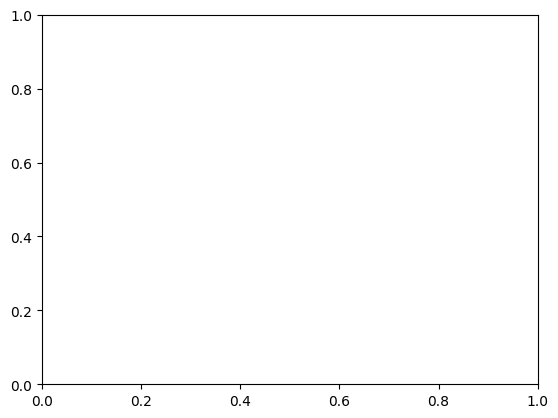

In [ ]:
# --- Gráfico 2D: Publicidad vs Ventas ---
plt.figure()
plt.scatter(X1, Y, color='blue', label="Datos reales")
plt.plot(X1, Y, color='red', label="Modelo ajustado ")
plt.title("Preci producto")
plt.xlabel("Porcentaje precio")
plt.ylabel("ganacias")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()